# Sesión 2 · Teoría
## Autocorrelación, ACF y PACF

**Estadística, Detección de Anomalías e Imputación de Series Temporales**
Posgrado en Ingeniería · Área Energía · IER-UNAM

---

### Objetivos de aprendizaje

Al terminar esta sesión, el estudiante será capaz de:

1. Explicar **por qué** la autocorrelación (vía ACF y PACF) es una herramienta diagnóstica central en series temporales.
2. Definir formalmente la **autocorrelación** y calcular ACF/PACF muestrales.
3. Leer una gráfica de ACF/PACF e identificar firmas de procesos AR, MA y estacionales.
4. Reconocer **estacionariedad** intuitivamente y conectarla con la forma de la ACF.
5. Detectar **gaps** y aplicar control de calidad básico antes de cualquier análisis.

## Importante

Las celdas de esta libreta usan **datos sintéticos** generados con NumPy. La intención es ver cada efecto *aislado*: una serie con autocorrelación pura, una con sólo estacionalidad, una con tendencia. En el laboratorio (013) llevaremos las mismas herramientas a la serie real de ClimaLab.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.random.seed(42)

## 1. ¿Por qué nos importan ACF y PACF?

Antes de la maquinaria, la pregunta honesta: **¿para qué sirven?** La respuesta corta es que la ACF (función de autocorrelación) y la PACF (autocorrelación parcial) son las **dos gráficas diagnósticas más útiles** que existen para series temporales. Resumen, en una imagen, *cómo* el pasado influye en el presente.

Conviene entender esto antes de calcular nada porque condiciona casi todo lo que vendrá en el resto del curso.

### 1.1 Porque la independencia ya no se cumple

En estadística clásica casi todo asume **observaciones independientes**: los intervalos de confianza, los $p$-valores de un $t$-test. Con datos meteorológicos eso es falso de raíz: la temperatura a las 14:01 está casi determinada por la de las 14:00. La ACF nos dice *qué tan falsa* es la suposición — y por tanto si podemos usar herramientas clásicas o necesitamos versiones que respeten la dependencia temporal.

> **Consecuencia práctica.** Aplicar un $z$-score "ingenuo" a una serie con fuerte autocorrelación marcará como anómalo todo un día caluroso, no porque sea raro, sino porque consecutivamente está por encima de la media. La ACF avisa de esto antes de que el resultado nos engañe.

### 1.2 Porque revelan periodicidades sin tener que asumirlas

Si no sabemos a priori cuál es el período natural de un fenómeno, la ACF lo descubre: aparece un pico en el rezago $k$ correspondiente al período. En meteorología sabemos que hay ciclo diario (1440 min, 24 h) y anual (365 d), pero la ACF nos lo *confirma* y, además, revela ciclos secundarios que tal vez no esperábamos.

### 1.3 Porque son la firma diagnóstica de los modelos ARIMA

En el Bloque 5 ajustaremos ARIMA y SARIMA para imputar gaps. La metodología clásica (Box-Jenkins) es:

| Si la ACF/PACF se ve así... | ...el modelo es |
|------------------------------|------------------|
| ACF decae exponencial, PACF corta tras rezago $p$ | $\mathrm{AR}(p)$ |
| ACF corta tras rezago $q$, PACF decae exponencial | $\mathrm{MA}(q)$ |
| Ambas decaen | $\mathrm{ARMA}(p,q)$ |
| Picos en rezagos múltiplos de $s$ | componente estacional con período $s$ |

Sin saber leer ACF/PACF, elegir órdenes $(p,d,q)$ es adivinar.

### 1.4 Porque validan que un modelo "ya capturó todo"

Después de ajustar cualquier modelo (regresión, descomposición, ARIMA), examinamos sus **residuales**. Si la ACF de los residuales muestra picos significativos, **el modelo dejó estructura sin capturar** y se puede mejorar. Es el *check-up* obligatorio.

### 1.5 Porque informan la estacionariedad

Una ACF que decae *muy lentamente* (sigue alta en rezagos grandes) es síntoma de **no estacionariedad** — típicamente una tendencia o una raíz unitaria. Esto motiva diferenciar la serie antes de modelar. Lo veremos en la sesión 6 con las pruebas ADF y KPSS, pero la ACF ya da la pista visual gratis.

### 1.6 Porque guían la imputación

Si dos observaciones consecutivas están fuertemente correlacionadas (ACF en lag 1 cercano a 1), un *forward fill* es una imputación razonable. Si no lo están, no. La ACF nos dice **cuánta información** carga cada vecino temporal sobre el dato faltante, y por tanto qué método de imputación tiene sentido.

---

> **Resumen.** ACF/PACF son las gafas que nos ponemos para **ver la estructura temporal** que está oculta en una serie cruda. Sin ellas, modelamos a ciegas. Con ellas, las decisiones de descomposición, detección de anomalías e imputación dejan de ser folklore y se vuelven justificables.

## 2. Autocorrelación: definición

Para una serie estacionaria $\{y_t\}$ con media $\mu$ y varianza $\sigma^2$, la **autocovarianza** en el rezago $k$ es:

$$\gamma_k = \mathrm{Cov}(y_t, y_{t-k}) = \mathbb{E}\!\left[(y_t - \mu)(y_{t-k} - \mu)\right]$$

Y la **autocorrelación** (ACF) es la versión normalizada:

$$\rho_k = \frac{\gamma_k}{\gamma_0} = \frac{\mathrm{Cov}(y_t, y_{t-k})}{\mathrm{Var}(y_t)} \in [-1, 1]$$

Lectura intuitiva:

- $\rho_k$ cercano a $+1$ → cuando $y_{t-k}$ está por arriba de la media, $y_t$ tiende a estarlo también.
- $\rho_k$ cercano a $-1$ → relación inversa (anti-persistencia).
- $\rho_k \approx 0$ → el rezago $k$ no aporta información lineal sobre $y_t$.

### Estimador muestral

Con $N$ observaciones:

$$\hat{\rho}_k = \frac{\sum_{t=k+1}^{N} (y_t - \bar{y})(y_{t-k} - \bar{y})}{\sum_{t=1}^{N} (y_t - \bar{y})^2}$$

### Bandas de confianza

Bajo la hipótesis nula de **ruido blanco**, $\hat{\rho}_k$ se distribuye aproximadamente normal con desviación estándar $1/\sqrt{N}$. Por eso las bandas que `statsmodels` dibuja a $\pm 1.96/\sqrt{N}$ separan rezagos *significativos* (fuera de la banda) de los compatibles con ruido blanco (dentro).

## 3. Tres series sintéticas para entrenar el ojo

Vamos a fabricar tres procesos canónicos y mirar su ACF/PACF. Es la mejor manera de aprender a leerlas: viendo formas conocidas con etiqueta puesta.

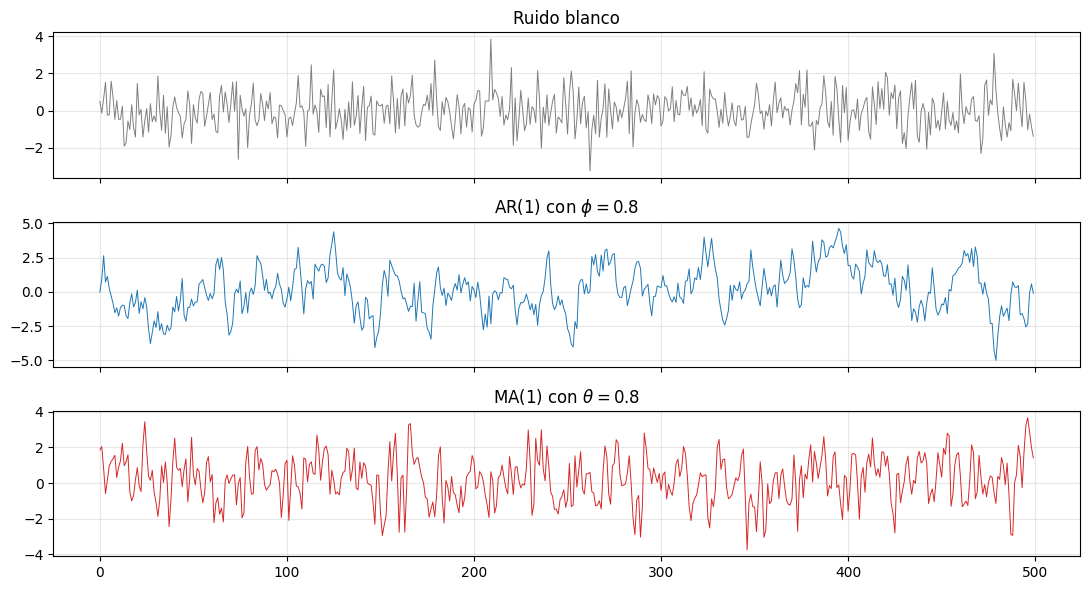

In [4]:
N = 500

# 3.1 Ruido blanco: y_t = ε_t
ruido = np.random.normal(0, 1, N)

# 3.2 AR(1): y_t = 0.8 * y_{t-1} + ε_t  (memoria que decae)
phi = 0.8
ar1 = np.zeros(N)
for t in range(1, N):
    ar1[t] = phi * ar1[t - 1] + np.random.normal(0, 1)

# 3.3 MA(1): y_t = ε_t + 0.8 * ε_{t-1}  (memoria de un solo paso)
theta = 0.8
eps = np.random.normal(0, 1, N + 1)
ma1 = eps[1:] + theta * eps[:-1]

fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
axes[0].plot(ruido, lw=0.7, color="C7"); axes[0].set_title("Ruido blanco")
axes[1].plot(ar1,   lw=0.7, color="C0"); axes[1].set_title("AR(1) con $\\phi=0.8$")
axes[2].plot(ma1,   lw=0.7, color="C3"); axes[2].set_title("MA(1) con $\\theta=0.8$")
plt.tight_layout()
plt.show()

### A simple vista

- El **ruido blanco** salta arriba y abajo sin memoria.
- El **AR(1)** muestra "rachas": cuando sube, se queda arriba un rato. Eso es persistencia.
- El **MA(1)** se ve casi como ruido, pero con una suavización mínima.

A simple vista cuesta distinguir AR(1) de MA(1). Aquí entran ACF y PACF.

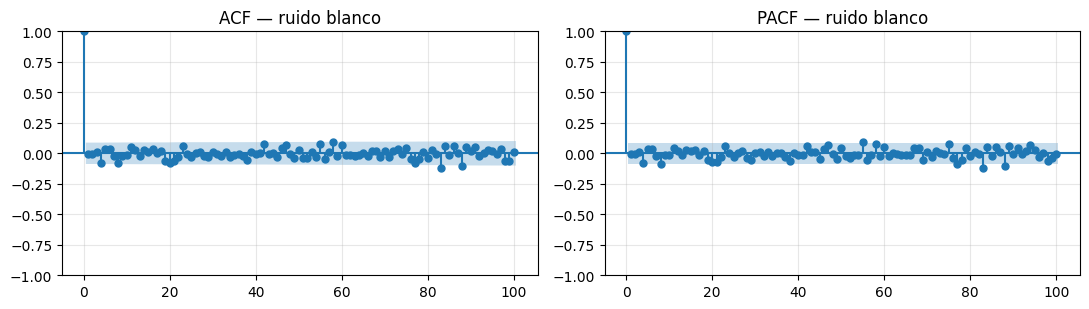

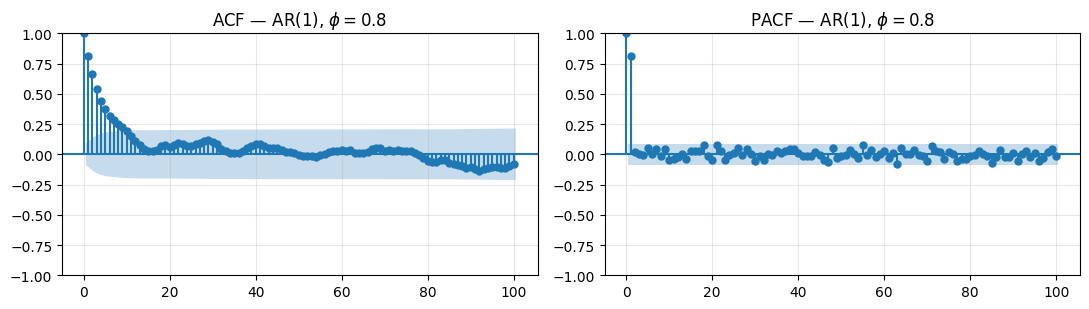

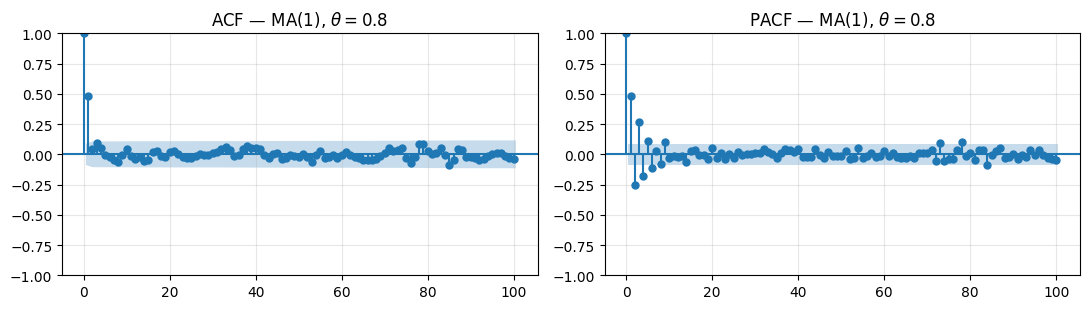

In [6]:
def acf_pacf(series, title, lags=100):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
    plot_acf(series, lags=lags, ax=axes[0]);  axes[0].set_title(f"ACF — {title}")
    plot_pacf(series, lags=lags, ax=axes[1], method="ywm"); axes[1].set_title(f"PACF — {title}")
    plt.tight_layout(); plt.show()

acf_pacf(ruido, "ruido blanco")
acf_pacf(ar1,   "AR(1), $\\phi=0.8$")
acf_pacf(ma1,   "MA(1), $\\theta=0.8$")

### Cómo se leen las bandas sombreadas

Las bandas son **intervalos de confianza al 95 %** bajo $H_0$: "el coeficiente verdadero $\rho_k$ vale cero". Su ancho sale del resultado asintótico de Bartlett: bajo ruido blanco,

$$\hat{\rho}_k \sim \mathcal{N}\!\left(0,\ \tfrac{1}{N}\right) \;\Longrightarrow\; \text{banda} = \pm\,\frac{1.96}{\sqrt{N}}$$

(El $1.96$ es el percentil 97.5 de la normal estándar; cubre el 95 % central.) Con $N=500$ esto da $\pm 0.088$, que es justo el ancho que se ve en la ACF de ruido blanco y en las PACF de arriba.

#### ¿Por qué la banda de la ACF del AR(1) parece una *trompeta*?

Porque `plot_acf` usa por defecto la **fórmula de Bartlett completa**, que reconoce que si los rezagos pequeños tienen correlación, los rezagos grandes "heredan" varianza:

$$\widehat{\mathrm{Var}}(\hat{\rho}_k) \approx \frac{1}{N}\left(1 + 2\sum_{i=1}^{k-1}\hat{\rho}_i^2\right)$$

La banda **arranca delgada en $k=1$ y se ensancha** conforme se acumula correlación previa. `plot_pacf` no hace esto y deja la banda rectangular.

#### Qué significa que un punto caiga *dentro* de la banda

| Posición del punto | Decisión | Lectura |
|---|---|---|
| **Dentro** | No rechazas $H_0$ | "Compatible con cero. No hay evidencia de correlación en este rezago." |
| **Fuera** | Rechazas $H_0$ | "Demasiado lejos de cero para ser azar. Hay correlación significativa." |

> **"Dentro de la banda" no significa "$\rho_k$ es exactamente cero".** Significa que con los $N$ datos que tienes no puedes *distinguirlo* de cero. Con más datos la banda se encogería y un valor pequeño que hoy queda dentro mañana podría salir afuera.

#### Tres trampas comunes

1. **Falsos positivos esperados.** Con bandas al 95 %, el 5 % de los rezagos saldrá fuera *aunque la serie sea ruido blanco puro*. Mirando 30 rezagos, 1 o 2 puntos afuera es lo normal.
2. **Sólo capturan dependencia lineal.** $\hat{\rho}_k = 0$ no descarta relaciones no lineales entre $y_t$ y $y_{t-k}$.
3. **Lo que importa es el patrón, no el punto suelto.** Un pico aislado en el lag 17 sin justificación física probablemente sea ruido; un pico en el lag 24 sobre datos horarios es el ciclo diario gritándote.

#### Lectura concreta de las gráficas de arriba

- **ACF y PACF de ruido blanco** — todos los puntos con $k\geq 1$ caen dentro: silencio estadístico, justo lo esperado.
- **ACF del AR(1)** — los primeros ~10 lags están claramente fuera → autocorrelación real que decae geométricamente. A partir del lag ~15 los puntos *entran* a la banda: la correlación verdadera sigue ahí (vale $0.8^{15} \approx 0.035$), pero ya es tan pequeña como el ruido muestral.
- **PACF del AR(1)** — sólo el lag 1 está fuera. Lectura textbook: "después de descontar $y_{t-1}$, no queda correlación parcial". Eso es **la firma** de un AR(1).

#### Cómo modificarlas en `statsmodels`

```python
plot_acf(serie, lags=30, alpha=0.05)                          # default: banda Bartlett
plot_acf(serie, lags=30, alpha=0.05, bartlett_confint=False)  # banda fija ±1.96/√N
plot_acf(serie, lags=30, alpha=0.01)                          # banda al 99 % (más ancha)
```

> **Regla del oficio.** Dentro de la banda = silencio estadístico, no hay nada que reportar en ese rezago. Fuera de la banda = señal — pero pregúntate si es un patrón coherente o un pico suelto antes de celebrar.

### Lo que enseña la firma

| Proceso | ACF | PACF |
|---------|-----|------|
| Ruido blanco | Todo dentro de las bandas | Todo dentro de las bandas |
| AR(1) | Decae **exponencialmente** | **Corta** después del rezago 1 |
| MA(1) | **Corta** después del rezago 1 | Decae exponencialmente |

Generalización (Box-Jenkins):

| Proceso | ACF | PACF |
|---------|-----|------|
| AR($p$) | decae | corta tras rezago $p$ |
| MA($q$) | corta tras rezago $q$ | decae |
| ARMA($p,q$) | decae | decae |

Esta tabla es la base para elegir órdenes $(p,q)$ en el Bloque 5.

## 4. PACF: ¿por qué necesitamos *otra* gráfica?

La ACF en el rezago $k$ contiene contribuciones de *todos* los rezagos intermedios. En un AR(1) la correlación entre $y_t$ y $y_{t-2}$ no es cero — pero **toda** esa correlación pasa por $y_{t-1}$, no es información nueva.

La **PACF** (autocorrelación parcial) en el rezago $k$ es la correlación entre $y_t$ y $y_{t-k}$ **después de remover** el efecto de $y_{t-1}, \dots, y_{t-k+1}$:

$$\phi_{kk} = \mathrm{Corr}(y_t, y_{t-k} \mid y_{t-1}, \dots, y_{t-k+1})$$

Operativamente: para cada $k$, ajusta una regresión

$$y_t = \phi_{k1} y_{t-1} + \phi_{k2} y_{t-2} + \dots + \phi_{kk} y_{t-k} + \varepsilon_t$$

y reporta $\phi_{kk}$, el último coeficiente.

> **Mnemónico.** ACF mide correlación *cruda* entre $y_t$ y $y_{t-k}$; PACF mide correlación *neta*, descontando los pasos intermedios.

## 5. Cuando hay estacionalidad

Las series meteorológicas tienen ciclo diario y anual. ¿Cómo se ve eso en la ACF?

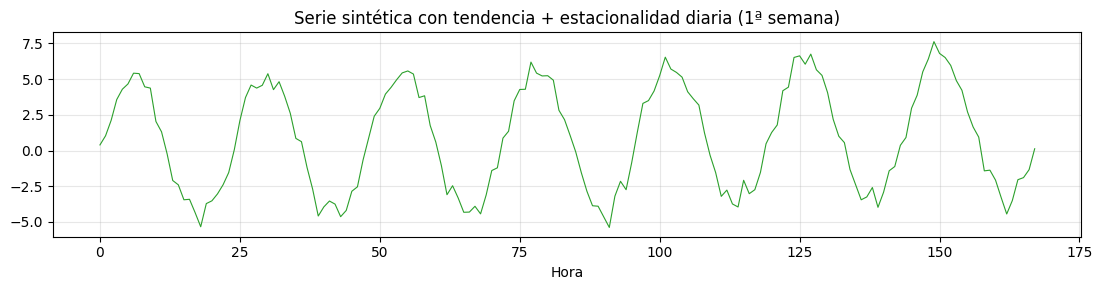

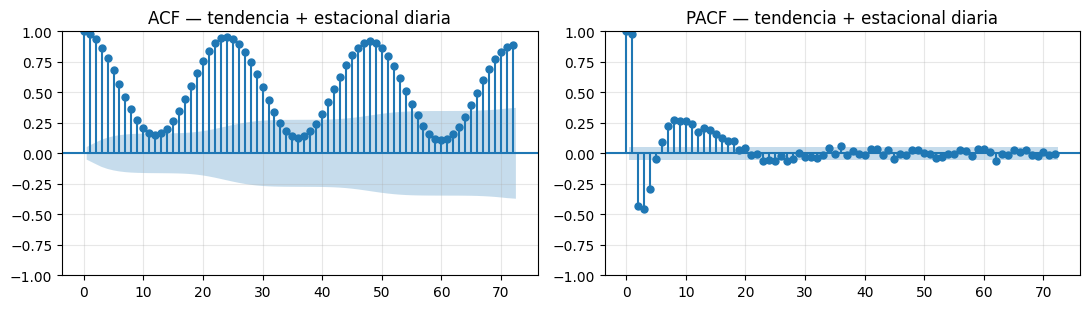

In [4]:
# Serie sintética con estacionalidad diaria (período 24 si fuera horaria)
n = 24 * 60   # 60 días de datos horarios
t = np.arange(n)
season = 5 * np.sin(2 * np.pi * t / 24)
trend  = 0.01 * t
noise  = np.random.normal(0, 0.5, n)
y_seasonal = trend + season + noise

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(t[:24*7], y_seasonal[:24*7], lw=0.8, color="C2")
ax.set_title("Serie sintética con tendencia + estacionalidad diaria (1ª semana)")
ax.set_xlabel("Hora")
plt.tight_layout(); plt.show()

acf_pacf(y_seasonal, "tendencia + estacional diaria", lags=72)

### Lo que vemos

- **Picos periódicos en la ACF cada 24 rezagos.** Esa es la firma del ciclo diario.
- **La ACF no decae a cero**, oscila. Eso suele ser síntoma de **no estacionariedad** (la tendencia hace que correlaciones lejanas no se desvanezcan).
- La **PACF** muestra picos en los primeros rezagos y luego se complica.

> **Regla de bolsillo.** Si tu serie tiene estacionalidad, **la ACF te lo grita**: aparecerán picos en los múltiplos del período. Esa es la base de la "detección de periodicidades" del laboratorio.

## 6. Estacionariedad (intuitiva)

Un proceso es **(débilmente) estacionario** si:

1. La media $\mathbb{E}[y_t]$ no depende de $t$.
2. La varianza $\mathrm{Var}(y_t)$ no depende de $t$.
3. La autocovarianza $\gamma_k = \mathrm{Cov}(y_t, y_{t-k})$ depende sólo de $k$, no de $t$.

En cristiano: **las propiedades estadísticas no cambian con el tiempo**.

### ¿Por qué importa?

Casi todos los modelos clásicos (ARIMA, SARIMA, regresión sobre rezagos) **asumen estacionariedad**. Si la serie tiene tendencia o cambia de varianza, el modelo se equivoca.

### ¿Cómo se detecta a ojo en la ACF?

| Patrón en la ACF | Probable diagnóstico |
|------------------|----------------------|
| Decae rápido a cero (en pocos rezagos) | Estacionaria |
| Decae **muy** lentamente, casi lineal | Tendencia / raíz unitaria → diferenciar |
| Picos periódicos sin decaer | Estacionalidad → diferenciación estacional |

En la sesión 6 formalizaremos esto con las pruebas **ADF** y **KPSS**. Por ahora basta con la pista visual.

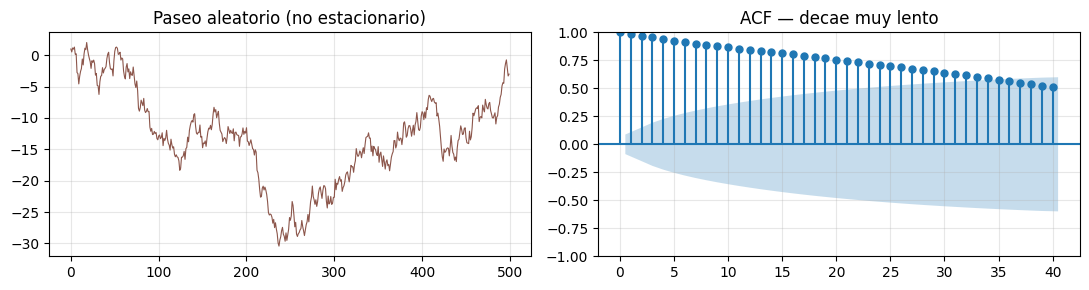

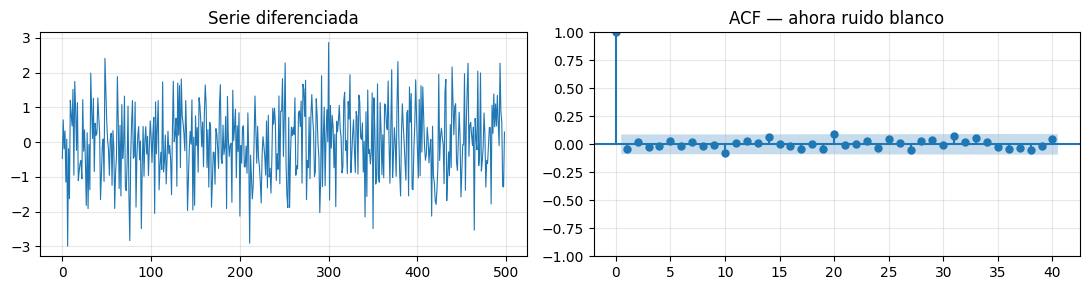

In [5]:
# Serie con tendencia (no estacionaria)
y_trend = np.cumsum(np.random.normal(0, 1, 500))   # paseo aleatorio

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(y_trend, lw=0.8, color="C5"); axes[0].set_title("Paseo aleatorio (no estacionario)")
plot_acf(y_trend, lags=40, ax=axes[1]); axes[1].set_title("ACF — decae muy lento")
plt.tight_layout(); plt.show()

# Después de diferenciar
y_diff = np.diff(y_trend)
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(y_diff, lw=0.8, color="C0"); axes[0].set_title("Serie diferenciada")
plot_acf(y_diff, lags=40, ax=axes[1]); axes[1].set_title("ACF — ahora ruido blanco")
plt.tight_layout(); plt.show()

**Mensaje.** Diferenciar (`y.diff()` en pandas) convierte un paseo aleatorio en ruido blanco. Esa es la "$d$" de ARIMA($p,d,q$): cuántas veces hay que diferenciar para alcanzar estacionariedad.

## 7. Gaps y control de calidad

Antes de calcular cualquier ACF sobre datos reales hay tres trampas que conviene desactivar.

### 7.1 Gaps temporales

Un *gap* es un hueco en el muestreo: faltó un dato, faltaron diez, o faltó una semana. Hay dos formas de "faltar":

- **Faltar como `NaN`** (la fila existe en el índice, el valor es `NaN`). Detectable con `df.isna()`.
- **Faltar de plano** (la fila no existe; el índice salta del minuto 14:00 al 14:05). **Mucho más insidioso**, porque pandas no avisa.

Para detectar el segundo tipo, comparamos el índice real con uno completo:

```python
esperado = pd.date_range(df.index.min(), df.index.max(), freq="1min")
faltantes = esperado.difference(df.index)
```

O calculamos `df.index.to_series().diff()` y miramos los valores distintos al paso esperado.

### 7.2 Por qué los gaps rompen la ACF

La fórmula muestral de $\hat{\rho}_k$ asume que entre $y_t$ y $y_{t-k}$ realmente hay $k$ pasos de tiempo. Si el índice tiene un hueco, esto deja de ser cierto: el rezago "1" puede ser de 1 minuto en algunos puntos y de 1 hora en otros. **El cálculo se contamina silenciosamente.**

`statsmodels` típicamente requiere que la serie sea continua y `acf` lanza error con `NaN`. Hay que **decidir** una política: rellenar los gaps cortos, descartar los tramos largos, o trabajar dentro de bloques continuos.

### 7.3 Control de calidad básico

Antes de cualquier análisis temporal, las cuatro revisiones mínimas:

1. **Rangos físicos.** ¿La temperatura está entre $-50$ y $60$ °C? ¿La humedad entre 0 y 100 %? ¿La presión cerca de la media local? Cualquier valor fuera es **basura**, no anomalía.
2. **Saturación de sensor.** Largos tramos con el mismo valor exacto (digamos, 50 minutos seguidos a 25.00 °C clavados) suelen indicar que el sensor se quedó pegado.
3. **Continuidad del índice.** Que no haya gaps inesperados, ni timestamps duplicados.
4. **Zona horaria.** ¿UTC, hora local? ¿Aplica horario de verano? Sin esto, el "ciclo diario" puede salir mal centrado.

> **Regla del oficio.** Antes de ACF/PACF, antes de descomponer, antes de cualquier modelo: **mira la serie**. Una gráfica cruda detecta el 90 % de los problemas que un análisis automático ocultaría.

## 8. Manejo temporal con pandas

Una rapidísima referencia de las operaciones que usaremos en el laboratorio.

| Operación | Código |
|-----------|--------|
| Asegurar índice datetime | `df.index = pd.to_datetime(df.index)` |
| Asignar zona horaria | `df.tz_localize("America/Mexico_City")` |
| Convertir entre zonas | `df.tz_convert("UTC")` |
| Rango esperado | `pd.date_range(inicio, fin, freq="1min")` |
| Resamplear a otra escala | `df.resample("1h").mean()` |
| Diferencia entre timestamps consecutivos | `df.index.to_series().diff()` |
| Detectar duplicados de tiempo | `df.index.duplicated()` |

> **Una nota sobre zonas horarias.** Si el cálculo del ciclo diario sale "torcido" (máximo a las 9 AM en lugar de 14:00, por ejemplo), casi siempre es porque los datos están en UTC y los estás tratando como locales (o viceversa). Es el bug número 1 en análisis meteorológico.

## 9. Síntesis

| Concepto | Para qué sirve |
|----------|----------------|
| ACF | Ver la dependencia *cruda* en cada rezago |
| PACF | Ver la dependencia *neta*, descontando intermedios |
| Bandas $\pm 1.96/\sqrt{N}$ | Significancia bajo H₀ de ruido blanco |
| ACF que decae lento | Sospechar no estacionariedad |
| Picos cada $s$ rezagos | Estacionalidad de período $s$ |
| Diferenciación | Receta para forzar estacionariedad |
| Gaps | Detectar antes de modelar; rompen ACF |

### Preguntas para reflexionar antes del laboratorio

1. Si tomamos la temperatura horaria de Temixco, ¿en qué rezago esperarías el primer pico estacional de la ACF?
2. ¿Por qué la PACF de un proceso AR(1) tiene **un solo** pico significativo y no dos?
3. Si la ACF de los residuales de tu modelo STL muestra picos cada 24 rezagos a resolución horaria, ¿qué te está diciendo eso del modelo?
4. Una estación reporta `tdb = -999` en algunos minutos. ¿Es un dato faltante, un outlier o un gap? ¿Cómo lo manejarías?

### Lectura recomendada (opcional)

- Hyndman & Athanasopoulos, *Forecasting: Principles and Practice* (3a ed.), capítulo 2.8 (Autocorrelación) y 9.1–9.5 (ARIMA). https://otexts.com/fpp3/
- Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015). *Time Series Analysis: Forecasting and Control* (5a ed.), capítulos 2–3.